In [5]:
import torch
import torch.nn as nn
import numpy as np

import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from tqdm import tqdm

# 0. Reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cpu')

# 1. Parâmetros físicos
OMEGA_Z = 2.0
T_START = 0.0
T_END   = 5.0
N_DATA  = 100
NOISE_LEVEL = 0.00

In [6]:
def omega_x_true(t):
    return (np.sin(2.0 * t) )

# 2. Geração dos dados
def bloch_rhs(t, y):
    Sx, Sy, Sz = y
    ox = omega_x_true(t)
    return [OMEGA_Z * Sy, -OMEGA_Z * Sx + ox * Sz, -ox * Sy]

y0 = [0.0, 0.0, 0.5]
t_eval = np.linspace(T_START, T_END, 1000)
sol = solve_ivp(bloch_rhs, [T_START, T_END], y0, t_eval=t_eval, method='RK45')

t_data_np = np.linspace(T_START, T_END, N_DATA)
Sx_data = np.interp(t_data_np, sol.t, sol.y[0]) + NOISE_LEVEL * np.random.randn(N_DATA)
Sy_data = np.interp(t_data_np, sol.t, sol.y[1]) + NOISE_LEVEL * np.random.randn(N_DATA)
Sz_data = np.interp(t_data_np, sol.t, sol.y[2]) + NOISE_LEVEL * np.random.randn(N_DATA)

t_data = torch.tensor(t_data_np, dtype=torch.float32).unsqueeze(1)
S_data = torch.tensor(np.stack([Sx_data, Sy_data, Sz_data], axis=1), dtype=torch.float32)

N_COLL = 3000
t_coll_np = np.linspace(T_START, T_END, N_COLL)
t_coll = torch.tensor(t_coll_np, dtype=torch.float32, requires_grad=True).unsqueeze(1)

# 3. Fourier Expansion (Refinado)
M_HARMONICS = 20
T_PERIOD = T_END - T_START
n_range = torch.arange(1, M_HARMONICS + 1, dtype=torch.float32).view(1, -1)

a0 = nn.Parameter(torch.zeros(1))
an = nn.Parameter(torch.zeros(1, M_HARMONICS))
bn = nn.Parameter(torch.zeros(1, M_HARMONICS))

def get_fourier_field(t):
    angles = (2.0 * np.pi / T_PERIOD) * t * n_range
    return a0 + torch.sum(an * torch.cos(angles) + bn * torch.sin(angles), dim=1, keepdim=True)

# 4. Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 3)
        )
    def forward(self, t):
        return self.net(t)

nn_state = MLP()

# 5. Loss
def compute_loss():
    S_pred = nn_state(t_data)
    L_data = torch.mean((S_pred - S_data) ** 2)
    
    S0_pred = nn_state(torch.zeros(1, 1))
    L_ic = torch.mean((S0_pred - torch.tensor([[0.0, 0.0, 0.5]])) ** 2)
    
    S_c = nn_state(t_coll)
    ox_c = get_fourier_field(t_coll)
    
    def grad(y, x): 
        return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]
    dSx = grad(S_c[:, 0:1], t_coll)
    dSy = grad(S_c[:, 1:2], t_coll)
    dSz = grad(S_c[:, 2:3], t_coll)
    
    res_x = dSx - OMEGA_Z * S_c[:, 1:2]
    res_y = dSy - (-OMEGA_Z * S_c[:, 0:1] + ox_c * S_c[:, 2:3])
    res_z = dSz - (-ox_c * S_c[:, 1:2])
    
    L_phys = torch.mean(res_x**2 + res_y**2 + res_z**2)
    return L_data + L_phys + 10.0 * L_ic

Treinando Fourier...


100%|██████████| 20000/20000 [02:57<00:00, 112.51it/s]


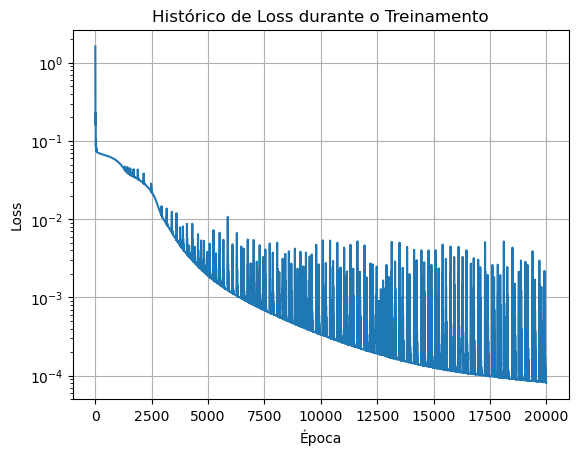

In [7]:
# 6. Trainingox_pred
optimizer = torch.optim.Adam(list(nn_state.parameters()) + [a0, an, bn], lr=1e-3)
#cheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20000)

loss_history = []
print("Treinando Fourier...")
for epoch in tqdm(range(20000)):
    optimizer.zero_grad()
    loss = compute_loss()
    
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Histórico de Loss durante o Treinamento')
plt.grid()
plt.savefig('loss_history.png')
plt.show()

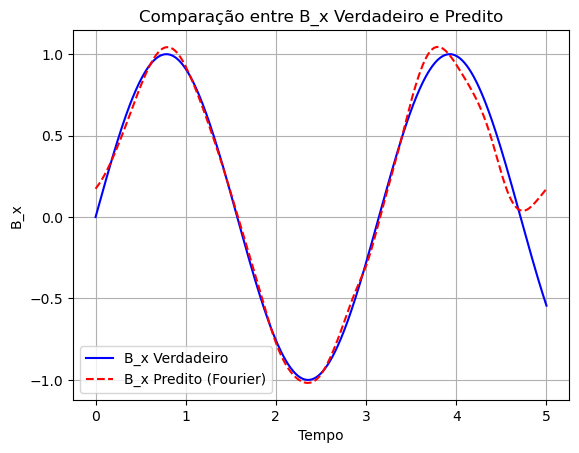

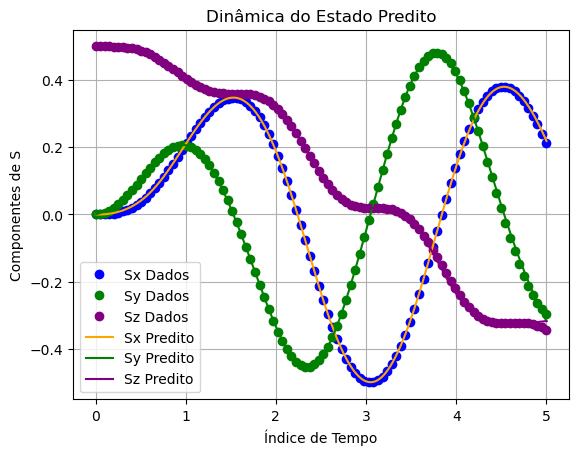

In [8]:
# 7. Eval
t_test_np = np.linspace(T_START, T_END, 1000)
t_test = torch.tensor(t_test_np, dtype=torch.float32).unsqueeze(1)
with torch.no_grad():
    ox_pred = get_fourier_field(t_test).numpy().flatten()
    S_pred = nn_state(t_test).numpy()

plt.plot(t_test_np, omega_x_true(t_test_np), label='B_x Verdadeiro', color='blue')
plt.plot(t_test_np, ox_pred, label='B_x Predito (Fourier)', color='red', linestyle='--')
plt.xlabel('Tempo')
plt.ylabel('B_x')
plt.title('Comparação entre B_x Verdadeiro e Predito')
plt.legend()
plt.grid()
plt.savefig('comparison.png')
plt.show()

plt.plot(t_data_np, Sx_data, label='Sx Dados', color='blue', linestyle='None', marker='o')
plt.plot(t_data_np, Sy_data, label='Sy Dados', color='green', linestyle='None', marker='o')
plt.plot(t_data_np, Sz_data, label='Sz Dados', color='purple', linestyle='None', marker='o')
plt.plot(t_test_np, S_pred[:, 0], label='Sx Predito', color='orange')
plt.plot(t_test_np, S_pred[:, 1], label='Sy Predito', color='green')
plt.plot(t_test_np, S_pred[:, 2], label='Sz Predito', color='purple')
plt.xlabel('Índice de Tempo')
plt.ylabel('Componentes de S')
plt.title('Dinâmica do Estado Predito')
plt.legend()
plt.grid()
plt.savefig('state_dynamics.png')
plt.show()